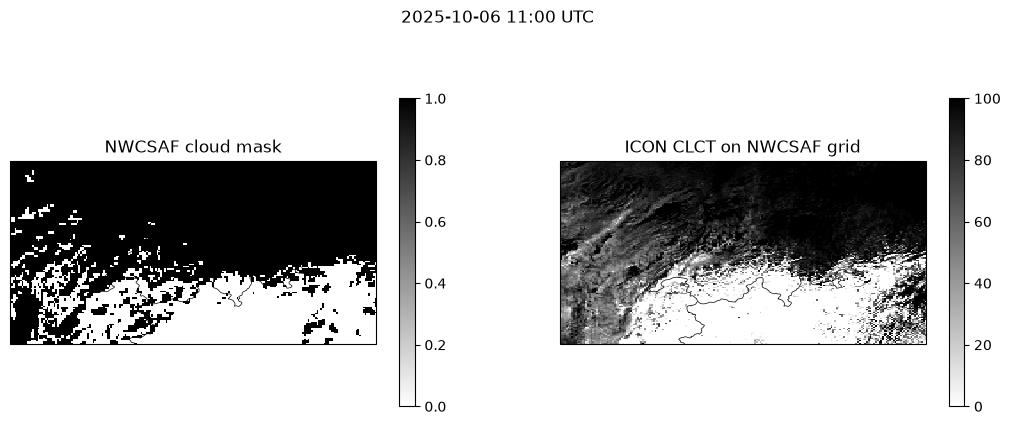

In [ ]:
# =============================================================================
# ICON CLCT -> NWCSAF grid
# =============================================================================
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

from datetime import datetime

import numpy as np
import xarray as xr
from scipy.interpolate import griddata

import earthkit.data as ekd

VALID_TIME = datetime(2025, 10, 6, 11)
BOX = [4, 12, 45, 49]          # lat lon range

NWCSAF_FILE = ("/scratch/mch/jdelbeke/nwcsaf/"
               f"MSG_nwcsaf_cosmo1eqc3km_{VALID_TIME:%Y%m%d%H%M}.nc")
ICON_FILE = ("/store_new/mch/msopr/jdelbeke/ICON_TST/801/FG25/det/"
             f"lff{VALID_TIME:%Y%m%d%H}")

# target grid and cloud mask
ds = xr.open_dataset(NWCSAF_FILE)
cma = ds["cma"].squeeze().values.astype(float)
cma[cma == 255] = np.nan
lon = ds["longitude"].values
lat = ds["latitude"].values
ds.close()
if lon.ndim == 1:
    lon, lat = np.meshgrid(lon, lat)

# ICON
field = ekd.from_source("file", ICON_FILE).to_fieldlist()
field = field.sel({"parameter.variable": "CLCT"})[0]
xa = field.to_xarray()
name = "CLCT" if "CLCT" in xa else list(xa.data_vars)[0]
lon_icon = np.asarray(xa["longitude"].values).ravel()
lat_icon = np.asarray(xa["latitude"].values).ravel()
clct_icon = np.asarray(xa[name].values).ravel()

# regrid
clct = griddata((lon_icon, lat_icon), clct_icon, (lon, lat), method="nearest")

# plot
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         subplot_kw={"projection": ccrs.PlateCarree()})

for ax, data, title, vmax in ((axes[0], cma, "NWCSAF cloud mask", 1),
                              (axes[1], clct, "ICON CLCT on NWCSAF grid", 100)):
    mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                         cmap="gray_r", vmin=0, vmax=vmax)
    ax.coastlines("10m")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.set_extent(BOX, crs=ccrs.PlateCarree())
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax, shrink=0.8)

fig.suptitle(f"{VALID_TIME:%Y-%m-%d %H:%M UTC}")
plt.show()

In [3]:
# =============================================================================
# Diagnostics before building the final regridder. Reads only, changes nothing.
#
# If you don't know the grid file path, try from the shell:
#   find /store /store_new /scratch -name '*icon*grid*.nc' 2>/dev/null | head -20
# The right one has uuidOfHGrid = 17643da2574959b644d254a3cd6e2bc0
# and 1147980 cells.
# =============================================================================
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

from datetime import datetime

import numpy as np
import xarray as xr
import earthkit.data as ekd

ICON_GRID_FILE = "/oprusers/osm/opr.inn/data/ICON_INPUT/ICON-CH1-EPS/icon_grid_0001_R19B08_mch.nc"          # <-- set this if you know it

VALID_TIME = datetime(2025, 10, 6, 11)
NWCSAF_FILE = ("/scratch/mch/jdelbeke/nwcsaf/"
               f"MSG_nwcsaf_cosmo1eqc3km_{VALID_TIME:%Y%m%d%H%M}.nc")
ICON_FILE = ("/store_new/mch/msopr/jdelbeke/ICON_TST/801/FG25/det/"
             f"lff{VALID_TIME:%Y%m%d%H}")

# --- 1. geometry library ------------------------------------------------------
try:
    import shapely
    print(f"[1] shapely {shapely.__version__}  "
          f"({'OK' if shapely.__version__ >= '2' else 'NEED >= 2'})")
except ImportError:
    print("[1] shapely MISSING")

# --- 2. ICON field ------------------------------------------------------------
f = ekd.from_source("file", ICON_FILE).to_fieldlist()
f = f.sel({"parameter.variable": "CLCT"})[0]
xa = f.to_xarray()
nm = "CLCT" if "CLCT" in xa else list(xa.data_vars)[0]
lon_i = np.asarray(xa["longitude"].values).ravel()
lat_i = np.asarray(xa["latitude"].values).ravel()
print(f"[2] ICON field: {lon_i.size} cells, var '{nm}', "
      f"lon {lon_i.min():.4f}..{lon_i.max():.4f}, "
      f"lat {lat_i.min():.4f}..{lat_i.max():.4f}")

# --- 3. ICON grid file --------------------------------------------------------
if not ICON_GRID_FILE:
    print("[3] ICON_GRID_FILE not set -- see the find command in the header")
else:
    with xr.open_dataset(ICON_GRID_FILE) as g:
        print(f"[3] grid file: {os.path.basename(ICON_GRID_FILE)}")
        print(f"    uuidOfHGrid attr : {g.attrs.get('uuidOfHGrid', '--')}")
        print(f"    (field says      : {f.metadata('uuidOfHGrid')})")
        have = [v for v in ("clon", "clat", "clon_vertices", "clat_vertices",
                            "cell_area") if v in g]
        print(f"    variables present: {have}")
        for v in have:
            print(f"      {v:15s} {tuple(g[v].shape)}  "
                  f"units={g[v].attrs.get('units', '--')}")
        if "clon" in g:
            cl = np.asarray(g["clon"].values)
            ca = np.asarray(g["clat"].values)
            if "rad" in str(g["clon"].attrs.get("units", "")):
                cl, ca = np.rad2deg(cl), np.rad2deg(ca)
            print(f"    cells            : {cl.size} "
                  f"({'MATCH' if cl.size == lon_i.size else 'MISMATCH'})")
            if cl.size == lon_i.size:
                d = max(np.abs(cl - lon_i).max(), np.abs(ca - lat_i).max())
                print(f"    ordering vs GRIB : max |diff| {d:.3e} deg "
                      f"({'OK' if d < 1e-4 else 'REORDERED -- problem'})")

# --- 4. NWCSAF target ---------------------------------------------------------
ds = xr.open_dataset(NWCSAF_FILE)
lon = np.asarray(ds["longitude"].values)
lat = np.asarray(ds["latitude"].values)
print(f"[4] NWCSAF coords: longitude{tuple(ds['longitude'].shape)}, "
      f"latitude{tuple(ds['latitude'].shape)}")
if lon.ndim == 2:
    lon, lat = lon[0, :], lat[:, 0]
print(f"    lat runs {'N->S' if lat[0] > lat[-1] else 'S->N'}, "
      f"dlat={np.median(np.diff(lat)):+.10f}, dlon={np.median(np.diff(lon)):.10f}")
print(f"    cma dtype {ds['cma'].dtype}, dims {ds['cma'].dims}")
print(f"    cma codes {np.unique(np.asarray(ds['cma'].values))[:10]}")
ds.close()

[1] shapely 2.1.2  (OK)
[2] ICON field: 1147980 cells, var 'CLCT', lon -0.8171..17.7106, lat 42.0279..50.5005
[3] grid file: icon_grid_0001_R19B08_mch.nc
    uuidOfHGrid attr : 17643da2-5749-59b6-44d2-54a3cd6e2bc0
    (field says      : 17643da2574959b644d254a3cd6e2bc0)
    variables present: ['clon', 'clat', 'clon_vertices', 'clat_vertices', 'cell_area']
      clon            (1147980,)  units=radian
      clat            (1147980,)  units=radian
      clon_vertices   (1147980, 3)  units=--
      clat_vertices   (1147980, 3)  units=--
      cell_area       (1147980,)  units=--
    cells            : 1147980 (MATCH)
    ordering vs GRIB : max |diff| 0.000e+00 deg (OK)
[4] NWCSAF coords: longitude(341, 482), latitude(341, 482)
    lat runs N->S, dlat=-0.0269794721, dlon=0.0387966805
    cma dtype float32, dims ('y', 'x')
    cma codes [0. 1.]


target grid: 341 x 482, dlon=0.0387966805 dlat=-0.0269794721
vertex mean vs cell centre: max 7.13e-04 deg
ICON triangles meeting the domain: 1147706
overlap pairs: 2402962 (2.09 per triangle)
partition of unity: max |sum(overlap)/area - 1| = 2.65e-12
target cells >= 0.999 covered: 131745/164362
mass conserved to 4.55e-15

matched cells              : 131745
satellite cloudy fraction  : 0.545
mean ICON CLCT             : 53.6 %
frequency-matched threshold: 54.2 % (at 50 % you get 0.566 cloudy)


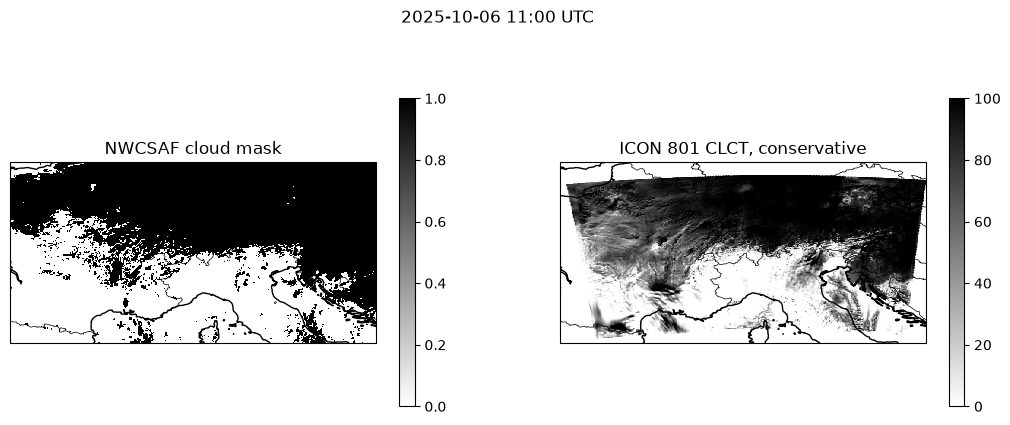

In [4]:
# =============================================================================
# ICON (native triangles) -> NWCSAF grid, first-order conservative.
#
#   CLCT(c) = sum_t A(t & c) * CLCT(t) / sum_t A(t & c)
#
# Every ICON triangle is clipped against every NWCSAF cell it touches and
# contributes in proportion to the overlapping area. No nearest-neighbour, no
# intermediate grid, no interpolation.
#
# The weights depend only on the two grids, which are static, so they are built
# once by build_weights() and reused by remap() for every field and timestep.
#
# Geometry note: clipping is planar in degrees. The cos(lat) metric varies by
# ~5e-4 relative across a 3 km cell and cancels in the numerator/denominator
# ratio, leaving an error ~1e-7 in the result -- orders of magnitude below the
# parallax and cloud-detection errors in this comparison.
#
# Nothing is written to disk unless WEIGHTS_CACHE is set to a path.
# =============================================================================
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

from datetime import datetime

import numpy as np
import xarray as xr
import shapely

import earthkit.data as ekd          # reading only; swap for cfgrib if needed

# ----------------------------------------------------------------------------
VALID_TIME = datetime(2025, 10, 6, 11)
EXP = "801"

NWCSAF_FILE = ("/scratch/mch/jdelbeke/nwcsaf/"
               f"MSG_nwcsaf_cosmo1eqc3km_{VALID_TIME:%Y%m%d%H%M}.nc")
ICON_FILE = (f"/store_new/mch/msopr/jdelbeke/ICON_TST/{EXP}/FG25/det/"
             f"lff{VALID_TIME:%Y%m%d%H}")
ICON_GRID_FILE = "/oprusers/osm/opr.inn/data/ICON_INPUT/ICON-CH1-EPS/icon_grid_0001_R19B08_mch.nc"     # <-- full path

DOMAIN = None            # None = whole NWCSAF grid, or [lonW, lonE, latS, latN]
MIN_COVERAGE = 0.999     # target cells less covered by ICON than this -> NaN
WEIGHTS_CACHE = None     # set to a .npz path to persist the weights
CHUNK = 200_000
PLOT = True

if shapely.__version__ < "2":
    raise RuntimeError(f"needs shapely >= 2, found {shapely.__version__}")


# ============================================================================
# GRIDS
# ============================================================================
def read_target(path, domain=None):
    """1-D coordinates and cloud mask of the NWCSAF grid."""
    ds = xr.open_dataset(path)
    cma = np.asarray(ds["cma"].squeeze().values, dtype="float64")
    cma[cma == 255] = np.nan
    lon2 = np.asarray(ds["longitude"].values)
    lat2 = np.asarray(ds["latitude"].values)
    ds.close()

    if lon2.ndim == 2:
        # stated to be a regular lat/lon grid; verify before collapsing to 1-D
        if (np.abs(lon2 - lon2[0, :]).max() > 1e-9
                or np.abs(lat2 - lat2[:, [0]]).max() > 1e-9):
            raise ValueError("2-D coordinates are not a regular lat/lon grid")
        lon, lat = lon2[0, :], lat2[:, 0]
    else:
        lon, lat = lon2, lat2

    dlon = float(np.median(np.diff(lon)))
    dlat = float(np.median(np.diff(lat)))
    if (np.abs(np.diff(lon) - dlon).max() > 1e-9
            or np.abs(np.diff(lat) - dlat).max() > 1e-9):
        raise ValueError("grid spacing is not uniform")

    if domain is not None:
        jx = np.where((lon >= domain[0]) & (lon <= domain[1]))[0]
        iy = np.where((lat >= domain[2]) & (lat <= domain[3]))[0]
        lon, lat = lon[jx], lat[iy]
        cma = cma[np.ix_(iy, jx)]

    return lon, lat, dlon, dlat, cma


def read_icon_cells(grid_file, n_expected, lon_c, lat_c):
    """ICON triangle vertices in degrees, validated against the field."""
    with xr.open_dataset(grid_file) as g:
        vlon = np.asarray(g["clon_vertices"].values, dtype="float64")
        vlat = np.asarray(g["clat_vertices"].values, dtype="float64")

    if vlon.shape[0] != n_expected:
        raise ValueError(f"grid file has {vlon.shape[0]} cells, "
                         f"field has {n_expected}")

    # clon_vertices/clat_vertices carry no units attribute in this file, so
    # radians are detected by magnitude rather than trusted from metadata
    if np.abs(vlat).max() <= np.pi + 1e-6:
        vlon, vlat = np.rad2deg(vlon), np.rad2deg(vlat)

    # the conversion and the vertex-to-cell pairing are both checked here: the
    # mean of the three vertices must land on the cell centre
    dv = max(np.abs(vlon.mean(axis=1) - lon_c).max(),
             np.abs(vlat.mean(axis=1) - lat_c).max())
    print(f"vertex mean vs cell centre: max {dv:.2e} deg")
    if dv > 1e-3:
        raise ValueError("vertices do not match the cell centres")

    return vlon, vlat


# ============================================================================
# WEIGHTS
# ============================================================================
def build_weights(lon, lat, dlon, dlat, vlon, vlat):
    """Overlap area of every ICON triangle with every NWCSAF cell it touches."""
    ny, nx = lat.size, lon.size
    ncell = ny * nx
    hx, hy = abs(dlon) / 2, abs(dlat) / 2

    # keep only triangles whose bounding box meets the target domain
    near = ((vlon.max(axis=1) >= lon.min() - hx)
            & (vlon.min(axis=1) <= lon.max() + hx)
            & (vlat.max(axis=1) >= lat.min() - hy)
            & (vlat.min(axis=1) <= lat.max() + hy))
    sub = np.where(near)[0]
    print(f"ICON triangles meeting the domain: {sub.size}")

    rings = np.stack([vlon[sub], vlat[sub]], axis=-1)
    rings = np.concatenate([rings, rings[:, :1, :]], axis=1)
    tri = shapely.polygons(rings)

    LON, LAT = np.meshgrid(lon, lat)
    cells = shapely.box((LON - hx).ravel(), (LAT - hy).ravel(),
                        (LON + hx).ravel(), (LAT + hy).ravel())

    ti, ci = shapely.STRtree(cells).query(tri, predicate="intersects")
    w = np.empty(ti.size)
    for a in range(0, ti.size, CHUNK):
        b = min(a + CHUNK, ti.size)
        w[a:b] = shapely.area(shapely.intersection(tri[ti[a:b]], cells[ci[a:b]]))
    keep = w > 0
    ti, ci, w = ti[keep], ci[keep], w[keep]
    print(f"overlap pairs: {ti.size} ({ti.size / sub.size:.2f} per triangle)")

    # --- correctness checks ---
    inside = ((vlon[sub].min(axis=1) > lon.min() - hx)
              & (vlon[sub].max(axis=1) < lon.max() + hx)
              & (vlat[sub].min(axis=1) > lat.min() - hy)
              & (vlat[sub].max(axis=1) < lat.max() + hy))
    got = np.bincount(ti, weights=w, minlength=sub.size)
    want = shapely.area(tri)
    print(f"partition of unity: max |sum(overlap)/area - 1| = "
          f"{np.abs(got[inside] / want[inside] - 1).max():.2e}")

    coverage = np.bincount(ci, weights=w, minlength=ncell) / (abs(dlon) * abs(dlat))
    print(f"target cells >= {MIN_COVERAGE} covered: "
          f"{(coverage >= MIN_COVERAGE).sum()}/{ncell}")

    return sub, ti, ci, w, coverage.reshape(ny, nx)


def remap(values, sub, ti, ci, w, coverage, shape):
    """Conservative average of a native ICON field onto the target grid."""
    v = np.asarray(values, dtype="float64").ravel()[sub]
    ok = np.isfinite(v[ti])
    ncell = shape[0] * shape[1]
    num = np.bincount(ci[ok], weights=w[ok] * v[ti][ok], minlength=ncell)
    den = np.bincount(ci[ok], weights=w[ok], minlength=ncell)
    out = np.full(ncell, np.nan)
    good = (coverage.ravel() >= MIN_COVERAGE) & (den > 0)
    out[good] = num[good] / den[good]
    return out.reshape(shape)


# ============================================================================
# RUN
# ============================================================================
lon, lat, dlon, dlat, CMA = read_target(NWCSAF_FILE, DOMAIN)
print(f"target grid: {lat.size} x {lon.size}, "
      f"dlon={dlon:.10f} dlat={dlat:+.10f}")

fl = ekd.from_source("file", ICON_FILE).to_fieldlist()
fl = fl.sel({"parameter.variable": "CLCT"})
xa = fl[0].to_xarray()
name = "CLCT" if "CLCT" in xa else list(xa.data_vars)[0]
lon_c = np.asarray(xa["longitude"].values).ravel()
lat_c = np.asarray(xa["latitude"].values).ravel()
clct_native = np.asarray(xa[name].values, dtype="float64").ravel()

vlon, vlat = read_icon_cells(ICON_GRID_FILE, clct_native.size, lon_c, lat_c)

if WEIGHTS_CACHE and os.path.exists(WEIGHTS_CACHE):
    z = np.load(WEIGHTS_CACHE)
    sub, ti, ci, w, coverage = (z["sub"], z["ti"], z["ci"], z["w"], z["coverage"])
    print(f"weights loaded from {WEIGHTS_CACHE}")
else:
    sub, ti, ci, w, coverage = build_weights(lon, lat, dlon, dlat, vlon, vlat)
    if WEIGHTS_CACHE:
        np.savez_compressed(WEIGHTS_CACHE, sub=sub, ti=ti, ci=ci, w=w,
                            coverage=coverage)
        print(f"weights saved to {WEIGHTS_CACHE}")

CLCT = remap(clct_native, sub, ti, ci, w, coverage, (lat.size, lon.size))

# --- conservation check on the covered interior ------------------------------
cell = abs(dlon) * abs(dlat)
m = np.isfinite(CLCT)
mass_out = np.nansum(CLCT[m]) * cell
mass_in = np.bincount(ci, weights=w * clct_native[sub][ti],
                      minlength=CLCT.size).reshape(CLCT.shape)[m].sum()
print(f"mass conserved to {abs(mass_out / mass_in - 1):.2e}")

# --- comparison ---------------------------------------------------------------
both = np.isfinite(CLCT) & np.isfinite(CMA)
obs = float(np.mean(CMA[both] == 1))
print(f"\nmatched cells              : {both.sum()}")
print(f"satellite cloudy fraction  : {obs:.3f}")
print(f"mean ICON CLCT             : {np.mean(CLCT[both]):.1f} %")
print(f"frequency-matched threshold: {np.quantile(CLCT[both], 1 - obs):.1f} % "
      f"(at 50 % you get {np.mean(CLCT[both] > 50):.3f} cloudy)")

result = xr.Dataset(
    {"cma": (("y", "x"), CMA, {"flag_values": "0 clear, 1 cloudy"}),
     "clct": (("y", "x"), CLCT, {"units": "%", "long_name":
                                 f"ICON {EXP} CLCT, conservative remap"}),
     "coverage": (("y", "x"), coverage)},
    coords={"longitude": ("x", lon), "latitude": ("y", lat)},
    attrs={"valid_time": VALID_TIME.isoformat(),
           "regridding": "first-order conservative (exact overlap area)"})

if PLOT:
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                             subplot_kw={"projection": ccrs.PlateCarree()})
    for ax, d, t, vmax in ((axes[0], CMA, "NWCSAF cloud mask", 1),
                           (axes[1], CLCT, f"ICON {EXP} CLCT, conservative", 100)):
        mesh = ax.pcolormesh(lon, lat, d, transform=ccrs.PlateCarree(),
                             cmap="gray_r", vmin=0, vmax=vmax, shading="nearest")
        ax.coastlines("10m")
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(t)
        fig.colorbar(mesh, ax=ax, shrink=0.8)
    fig.suptitle(f"{VALID_TIME:%Y-%m-%d %H:%M UTC}")
    plt.show()

In [7]:
# =============================================================================
# PARALLAX DIAGNOSTIC v3
#
# Paste after icon_to_nwcsaf_conservative_final.py. Needs from it:
#   lon, lat, dlon, dlat, CMA, ICON_FILE, NWCSAF_FILE,
#   sub, ti, ci, w, coverage, remap()
#
# The ICON file is reloaded here, because fl was already narrowed to CLCT in
# the main script and the layer fields would come back empty.
#
# Test: if the mask is not parallax corrected, an observed cloud at height z
# sits about 1.38 * z away from its true position, roughly due north for
# Switzerland seen from MSG at 0 deg. Shifting the observation back south
# should then improve its correlation with the matching ICON layer, and the
# best shift should grow with z. If the mask is corrected, the best shift is
# near zero in every layer.
#
# The cell set is fixed and only the observation moves, so scores at different
# shifts are comparable.
# =============================================================================
import numpy as np
import xarray as xr
import earthkit.data as ekd
from scipy.ndimage import minimum_filter

MAX_DI, MAX_DJ = 12, 6         # cells; 12 rows = 36 km, enough for an 8 km top
LAYERS = [("low", "CLCL", 0, 2000),      # bands chosen to approximate ICON's
          ("mid", "CLCM", 2000, 7000),   # pressure based layer definitions
          ("high", "CLCH", 7000, 99000)]

# ----------------------------------------------------------------------------
# 1. prediction
# ----------------------------------------------------------------------------
R_E, R_S, SAT_LON = 6371.0, 42164.0, 0.0
lat0, lon0 = float(np.mean(lat)), float(np.mean(lon))
la, dlo = np.deg2rad(lat0), np.deg2rad(lon0 - SAT_LON)

psi = np.arccos(np.cos(la) * np.cos(dlo))
vza = np.arctan2(R_S * np.sin(psi), R_S * np.cos(psi) - R_E)
# bearing from the domain towards the sub-satellite point; the correction
# points this way, the apparent displacement points the other way
brg = np.arctan2(np.sin(-dlo), -np.sin(la) * np.cos(-dlo))

km_lat = abs(dlat) * 111.32
km_lon = abs(dlon) * 111.32 * np.cos(la)
south_per_km = -np.tan(vza) * np.cos(brg) / km_lat     # positive = southward
east_per_km = np.tan(vza) * np.sin(brg) / km_lon       # negative = westward

print(f"centre {lat0:.2f}N {lon0:.2f}E, viewing zenith {np.rad2deg(vza):.1f} deg, "
      f"displacement {np.tan(vza):.2f} x height")
print("predicted shift of the mask to undo parallax (cells):")
for z in (1, 2, 5, 8):
    print(f"  top {z} km -> {z * south_per_km:+.2f} south, "
          f"{z * east_per_km:+.2f} east")

# ----------------------------------------------------------------------------
# 2. ICON layer cloud fractions, remapped with the existing weights
# ----------------------------------------------------------------------------
full = ekd.from_source("file", ICON_FILE).to_fieldlist()

layers = {}
for _, param, _, _ in LAYERS:
    sel = full.sel({"parameter.variable": param})
    if len(sel) == 0:
        print(f"  {param}: not in the GRIB")
        continue
    xa = sel[0].to_xarray()
    nm = param if param in xa else list(xa.data_vars)[0]
    native = np.asarray(xa[nm].values, dtype="float64").ravel()
    layers[param] = remap(native, sub, ti, ci, w, coverage, CMA.shape)
print(f"ICON layers available: {sorted(layers)}")
if not layers:
    raise SystemExit("no layer fields; add CLCL/CLCM/CLCH to the fieldextra output")

# ----------------------------------------------------------------------------
# 3. observed cloud-top height
# ----------------------------------------------------------------------------
ds = xr.open_dataset(NWCSAF_FILE)
h = np.asarray(ds["ctth_alti"].squeeze().values, dtype=float)
ds.close()
h[h > 3e4] = np.nan
print(f"ctth_alti: {np.isfinite(h).sum()} valid, "
      f"{np.nanpercentile(h, [5, 50, 95]).round(0)} m at p5/p50/p95")

# a cell is usable if the mask is valid and, when cloudy, has a height
base = np.isfinite(CMA) & ((CMA == 0) | np.isfinite(h))
base &= np.isfinite(next(iter(layers.values())))
common = minimum_filter(base.astype(np.uint8),
                        size=(2 * MAX_DI + 1, 2 * MAX_DJ + 1)) > 0
print(f"fixed cell set: {common.sum()} cells")


def shift(a, di, dj):
    """Positive di moves content southward, positive dj eastward."""
    out = np.full_like(a, np.nan)
    ny, nx = a.shape
    out[max(di, 0):ny + min(di, 0), max(dj, 0):nx + min(dj, 0)] = \
        a[max(-di, 0):ny + min(-di, 0), max(-dj, 0):nx + min(-dj, 0)]
    return out


def corr(a, b, m):
    x, y = a[m], b[m]
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok] - x[ok].mean(), y[ok] - y[ok].mean()
    d = np.sqrt((x * x).sum() * (y * y).sum())
    return float((x * y).sum() / d) if d > 0 else np.nan


def refine(v, k):
    """Sub-cell offset of the extremum of a parabola through three samples."""
    if 0 < k < len(v) - 1 and np.all(np.isfinite(v[k - 1:k + 2])):
        a, b, c = v[k - 1], v[k], v[k + 1]
        d = a - 2 * b + c
        return (a - c) / (2 * d) if abs(d) > 1e-12 else 0.0
    return 0.0


# ----------------------------------------------------------------------------
# 4. search
# ----------------------------------------------------------------------------
print("\nbest shift per layer (positive = south / east):")
for name, param, lo, hi in LAYERS:
    if param not in layers:
        continue

    # 1 where this layer is observed, 0 where clear or a different layer,
    # NaN where cloudy but no height retrieval
    obs = np.full(CMA.shape, np.nan)
    obs[CMA == 0] = 0.0
    cl = (CMA == 1) & np.isfinite(h)
    obs[cl] = ((h[cl] >= lo) & (h[cl] < hi)).astype(float)

    mod = layers[param]
    grid = np.array([[corr(shift(obs, di, dj), mod, common)
                      for dj in range(-MAX_DJ, MAX_DJ + 1)]
                     for di in range(-MAX_DI, MAX_DI + 1)])

    i, j = np.unravel_index(np.nanargmax(grid), grid.shape)
    di, dj = i - MAX_DI, j - MAX_DJ
    fi, fj = di + refine(grid[:, j], i), dj + refine(grid[i, :], j)

    r_best, r_zero, r_worst = grid[i, j], grid[MAX_DI, MAX_DJ], np.nanmin(grid)
    edge = abs(di) == MAX_DI or abs(dj) == MAX_DJ
    zkm = (lo + min(hi, 12000)) / 2000

    print(f"  {name:4s} vs {param}  n_obs={int(np.nansum(obs)):6d}")
    print(f"       best {fi:+6.2f} south {fj:+6.2f} east    "
          f"r {r_best:.3f}  (zero shift {r_zero:.3f}, worst {r_worst:.3f})"
          + ("   *** AT SEARCH EDGE ***" if edge else ""))
    print(f"       predicted {zkm * south_per_km:+6.2f} south "
          f"{zkm * east_per_km:+6.2f} east   (for a {zkm:.1f} km top)")

centre 46.50N 8.25E, viewing zenith 54.1 deg, displacement 1.38 x height
predicted shift of the mask to undo parallax (cells):
  top 1 km -> +0.45 south, -0.09 east
  top 2 km -> +0.90 south, -0.18 east
  top 5 km -> +2.25 south, -0.46 east
  top 8 km -> +3.61 south, -0.73 east
ICON layers available: ['CLCH', 'CLCL', 'CLCM']
ctth_alti: 80526 valid, [ 884. 3921. 7119.] m at p5/p50/p95
fixed cell set: 57363 cells

best shift per layer (positive = south / east):
  low  vs CLCL  n_obs= 20236
       best -10.45 south  +6.00 east    r 0.227  (zero shift 0.221, worst 0.203)   *** AT SEARCH EDGE ***
       predicted  +0.45 south  -0.09 east   (for a 1.0 km top)
  mid  vs CLCM  n_obs= 55865
       best -12.00 south  +6.00 east    r 0.845  (zero shift 0.816, worst 0.780)   *** AT SEARCH EDGE ***
       predicted  +2.03 south  -0.41 east   (for a 4.5 km top)
  high vs CLCH  n_obs=  4425
       best  -0.77 south  +1.42 east    r 0.399  (zero shift 0.393, worst 0.324)
       predicted  +4.28 south 